In [1]:
import sys; sys.path.append('..')  # shared utils.py lives in the repo root
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyro
import pyro.distributions as dist
from pyro import poutine
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.decomposition import PCA
from scipy.stats import t as scipy_t
from torch.utils.data import DataLoader, TensorDataset
from dmm_features import DMMFeatures
from utils import log_returns, rogers_satchell_rv

c:\Users\mikah\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
spy = pd.read_csv('../data/spy_ohlcv.csv', index_col=0, parse_dates=True, skiprows=[1, 2])

pool = {
    'ret':    log_returns(spy['Close']),
    'rv':     rogers_satchell_rv(spy).clip(lower=1e-8),
    'VIX':    pd.read_csv('../data/fred_vix.csv',    index_col=0, parse_dates=True).squeeze(),
    'T10Y3M': pd.read_csv('../data/fred_t10y3m.csv', index_col=0, parse_dates=True).squeeze(),
    'BAA10Y': pd.read_csv('../data/fred_baa10y.csv', index_col=0, parse_dates=True).squeeze(),
    'DGS2':   pd.read_csv('../data/fred_dgs2.csv',   index_col=0, parse_dates=True).squeeze(),
}

for name, s in pool.items():
    valid = s.dropna()
    print(f"  {name:<8} {valid.index[0].date()} \u2192 {valid.index[-1].date()}  ({len(valid)} rows)")

  ret      1993-02-01 → 2026-05-15  (8380 rows)
  rv       1993-01-29 → 2026-05-15  (8381 rows)
  VIX      1990-01-02 → 2026-05-14  (9186 rows)
  T10Y3M   1982-01-04 → 2026-05-15  (11095 rows)
  BAA10Y   1986-01-02 → 2026-05-14  (10092 rows)
  DGS2     1976-06-01 → 2026-05-14  (12485 rows)


In [3]:
# ── FEATURE CONFIG ────────────────────────────────────────────────────────────
FEATURES = [
    ('ret',    'studentt'),
    ('rv',     'lognormal'),
#    ('VIX',    'lognormal'),
#    ('T10Y3M', 'normal'),
]
# ─────────────────────────────────────────────────────────────────────────────

feat_names  = [f[0] for f in FEATURES]
feat_types  = {f[0]: f[1] for f in FEATURES}
n_studentt  = sum(1 for _, t in FEATURES if t == 'studentt')
n_lognormal = sum(1 for _, t in FEATURES if t == 'lognormal')
n_normal    = sum(1 for _, t in FEATURES if t == 'normal')
x_dim       = len(FEATURES)

print(f"Features: {feat_names}")
print(f"  studentt={n_studentt}  lognormal={n_lognormal}  normal={n_normal}  x_dim={x_dim}")

Features: ['ret', 'rv']
  studentt=1  lognormal=1  normal=0  x_dim=2


In [4]:
trading_days = pool['ret'].dropna().index

aligned = pd.concat(
    [pool[name].reindex(trading_days, method='ffill').rename(name) for name in feat_names],
    axis=1
).dropna().sort_index()

print(f"Aligned dataset: {aligned.index[0].date()} \u2192 {aligned.index[-1].date()}  ({len(aligned)} rows)")
aligned.describe()

Aligned dataset: 1993-02-01 → 2026-05-15  (8380 rows)


,ret,rv
count,8380.000000,8.380000e+03
mean,0.000408,7.714262e-03
std,0.011714,6.169932e-03
min,-0.115887,1.000000e-08
25%,-0.004325,4.054098e-03
50%,0.000682,6.184425e-03
75%,0.005932,9.432116e-03
max,0.135577,8.746396e-02


In [5]:
K       = 15
n_train = 4500
n_test  = 3000

train_raw = aligned.iloc[:n_train]
test_raw  = aligned.iloc[n_train:n_train + n_test]

norm_params = {}
for name, etype in FEATURES:
    if etype in ('studentt', 'normal'):
        norm_params[name] = {'mean': train_raw[name].mean(), 'std': train_raw[name].std()}
    else:
        norm_params[name] = {'mean': train_raw[name].mean()}

def normalize(df):
    out = df.copy()
    for name, etype in FEATURES:
        p = norm_params[name]
        if etype in ('studentt', 'normal'):
            out[name] = (df[name] - p['mean']) / p['std']
        else:
            out[name] = df[name] / p['mean']
    return out

train_norm = normalize(train_raw)
test_norm  = normalize(test_raw)

print(f"train: {len(train_norm)} rows  ({train_raw.index[0].date()} \u2192 {train_raw.index[-1].date()})")
print(f"test:  {len(test_norm)} rows   ({test_raw.index[0].date()} \u2192 {test_raw.index[-1].date()})")

train: 4500 rows  (1993-02-01 → 2010-12-09)
test:  3000 rows   (2010-12-10 → 2022-11-09)


In [6]:
T = 15
train_arr   = train_norm.values.astype(np.float32)
n_sequences = len(train_arr) // T
train_data  = torch.tensor(train_arr[:n_sequences * T].reshape(n_sequences, T, x_dim))
print(f"train dataset: {train_data.shape}  ({n_sequences} sequences of length {T})")

# full-length tensors for inference (no chunking)
train_data_seq = torch.tensor(train_norm.values.astype(np.float32)).unsqueeze(0)  # (1, n_train, x_dim)
test_data      = torch.tensor(test_norm.values.astype(np.float32)).unsqueeze(0)   # (1, n_test, x_dim)
print(f"train_data_seq: {train_data_seq.shape}")
print(f"test_data:      {test_data.shape}")

train dataset: torch.Size([300, 15, 2])  (300 sequences of length 15)
train_data_seq: torch.Size([1, 4500, 2])
test_data:      torch.Size([1, 3000, 2])


In [7]:
batch_size = 32
loader = DataLoader(TensorDataset(train_data), batch_size=batch_size, shuffle=True)
print(f"batches per epoch: {len(loader)}")

batches per epoch: 10


In [8]:
z_dim          = 8
hidden_dim     = 64
rnn_hidden_dim = 64
rnn_num_layers = 1

dmm = DMMFeatures(
    n_studentt=n_studentt,
    n_lognormal=n_lognormal,
    n_normal=n_normal,
    z_dim=z_dim,
    hidden_dim=hidden_dim,
    rnn_hidden_dim=rnn_hidden_dim,
    rnn_num_layers=rnn_num_layers,
)

c:\Users\mikah\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


In [9]:
def elbo_terms(model, guide, x):
    guide_trace = poutine.trace(guide).get_trace(x)
    model_trace = poutine.trace(poutine.replay(model, trace=guide_trace)).get_trace(x)
    guide_trace.compute_log_prob()
    model_trace.compute_log_prob()
    reconstruction = sum(
        site['log_prob_sum']
        for site in model_trace.nodes.values()
        if site['type'] == 'sample' and site['is_observed']
    )
    kl = sum(
        guide_trace.nodes[name]['log_prob_sum'] - model_trace.nodes[name]['log_prob_sum']
        for name, site in guide_trace.nodes.items()
        if site['type'] == 'sample'
    )
    return reconstruction.item(), kl.item()

In [10]:
pyro.clear_param_store()
optimizer = Adam({'lr': 1e-3})
svi = SVI(dmm.model, dmm.guide, optimizer, loss=Trace_ELBO())

num_epochs = 301
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for (batch,) in loader:
        epoch_loss += svi.step(batch)
    if epoch % 50 == 0:
        with torch.no_grad():
            recon, kl = elbo_terms(dmm.model, dmm.guide, train_data)
        print(f"epoch {epoch:4d}  loss: {epoch_loss / len(loader):10.4f}  recon: {recon:10.4f}  kl: {kl:10.4f}")

epoch    0  loss:  2324.2047  recon: -15652.8467  kl:  4382.5039
epoch   50  loss:  1102.7985  recon: -9976.7578  kl:   936.8145
epoch  100  loss:   956.7100  recon: -8104.4380  kl:  1490.7490
epoch  150  loss:   870.0330  recon: -7159.4604  kl:  1560.2625
epoch  200  loss:   837.2911  recon: -6607.4937  kl:  1671.9164
epoch  250  loss:   830.4074  recon: -6512.8828  kl:  1626.9393
epoch  300  loss:   798.8500  recon: -6481.9287  kl:  1531.7172


In [11]:
# infer posterior mean z_t for each split
# infer() returns (batch, T-K, z_dim); we squeeze the batch dim
with torch.no_grad():
    z_means_train, _ = dmm.infer(train_data_seq, K)   # (1, n_train-K, z_dim)
    z_means_test,  _ = dmm.infer(test_data,      K)   # (1, n_test-K,  z_dim)

z_train = z_means_train.squeeze(0).numpy()   # (n_train-K, z_dim)
z_test  = z_means_test.squeeze(0).numpy()    # (n_test-K,  z_dim)

# dates aligned to the inferred steps (first K obs consumed as context)
dates_train = train_raw.index[K:]
dates_test  = test_raw.index[K:]

print(f"z_train: {z_train.shape}  {dates_train[0].date()} \u2192 {dates_train[-1].date()}")
print(f"z_test:  {z_test.shape}   {dates_test[0].date()} \u2192 {dates_test[-1].date()}")

z_train: (4485, 8)  1993-02-23 → 2010-12-09
z_test:  (2985, 8)   2011-01-03 → 2022-11-09


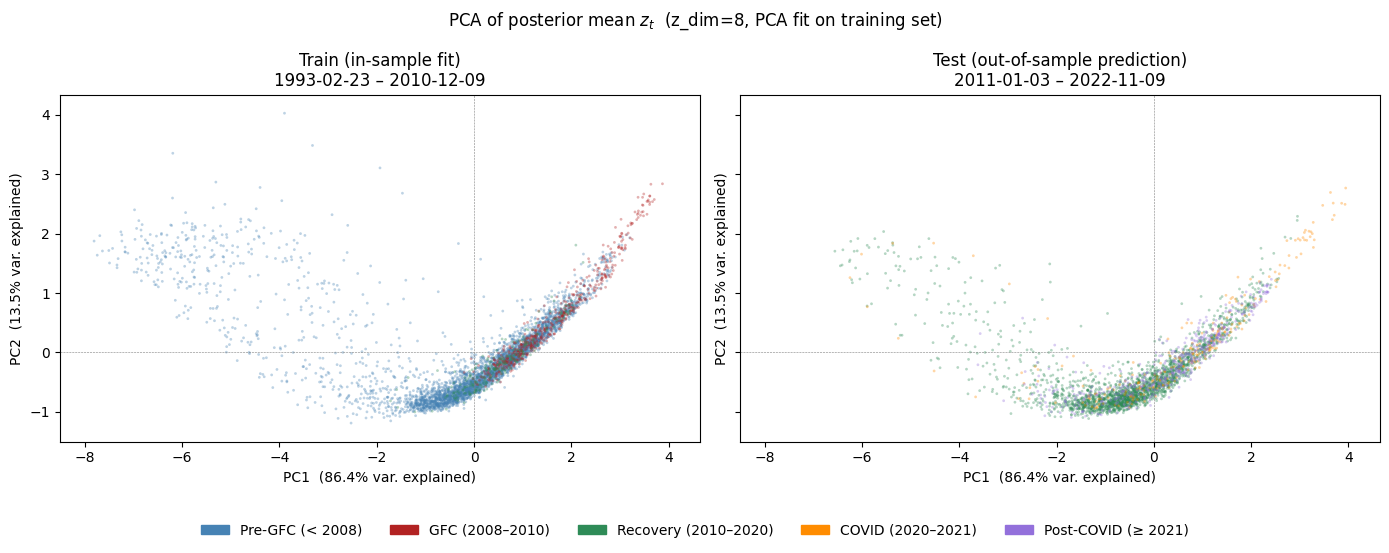

In [13]:
# ── PCA on latent states ───────────────────────────────────────────────────
# PCA is fit on training z_t only; test z_t are projected into the same space.
# This lets us see whether test regimes land in familiar vs. novel regions.

REGIMES = [
    (pd.Timestamp('2008-01-01'), 'steelblue',    'Pre-GFC (< 2008)'),
    (pd.Timestamp('2010-01-01'), 'firebrick',    'GFC (2008–2010)'),
    (pd.Timestamp('2020-01-01'), 'seagreen',     'Recovery (2010–2020)'),
    (pd.Timestamp('2021-01-01'), 'darkorange',   'COVID (2020–2021)'),
    (None,                       'mediumpurple', 'Post-COVID (≥ 2021)'),
]

def assign_colors(dates):
    colors = []
    for d in dates:
        for cutoff, color, _ in REGIMES:
            if cutoff is None or d < cutoff:
                colors.append(color)
                break
    return colors

pca = PCA(n_components=2)
pca.fit(z_train)
pc_train = pca.transform(z_train)
pc_test  = pca.transform(z_test)

c_train = assign_colors(dates_train)
c_test  = assign_colors(dates_test)

var_exp = pca.explained_variance_ratio_

# shared axis limits so both panels are directly comparable
all_pc  = np.vstack([pc_train, pc_test])
pad     = 0.06
x_range = all_pc[:, 0].max() - all_pc[:, 0].min()
y_range = all_pc[:, 1].max() - all_pc[:, 1].min()
xlim = (all_pc[:, 0].min() - pad * x_range, all_pc[:, 0].max() + pad * x_range)
ylim = (all_pc[:, 1].min() - pad * y_range, all_pc[:, 1].max() + pad * y_range)

legend_handles = [
    mpatches.Patch(color=color, label=label)
    for _, color, label in REGIMES
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

panels = [
    (axes[0], pc_train, c_train,
     f'Train (in-sample fit)\n{dates_train[0].date()} – {dates_train[-1].date()}'),
    (axes[1], pc_test,  c_test,
     f'Test (out-of-sample prediction)\n{dates_test[0].date()} – {dates_test[-1].date()}'),
]

for ax, pc, colors, title in panels:
    ax.scatter(pc[:, 0], pc[:, 1], c=colors, alpha=0.35, s=4, linewidths=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(f'PC1  ({var_exp[0]:.1%} var. explained)')
    ax.set_ylabel(f'PC2  ({var_exp[1]:.1%} var. explained)')
    ax.set_title(title)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.10),
    frameon=False,
    fontsize=10,
)
fig.suptitle(
    f'PCA of posterior mean $z_t$  (z_dim={z_dim}, PCA fit on training set)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig('pca_zt.png', dpi=150, bbox_inches='tight')
plt.show()
